**Mini-Project: Binary Text Classification with IMDB Dataset (CNN)**


Ce mini-projet initie à la classification de texte, une tâche fondamentale en NLP. Contrairement aux données numériques simples ou aux images, le texte nécessite un prétraitement spécifique pour être compris par les réseaux de neurones.

L'idée ici est de :

* Prétraiter du texte : transformer des mots en nombres, puis en vecteurs binaires. C'est une étape cruciale pour les modèles de Deep Learning en NLP.

* Construire un réseau de neurones feedforward simple avec Keras/TensorFlow pour une introduction aux couches Dense et aux fonctions d'activation pour la classification.

* Gérer le surapprentissage (overfitting) : en utilisant des ensembles de validation et en visualisant les métriques, comment détecter si le modèle apprend trop spécifiquement les données d'entraînement.

Le fait que le jeu de données IMDB soit déjà encodé en séquences d'entiers simplifie un peu la première partie du prétraitement,  permettant de vous concentrer sur la vectorisation et la construction du modèle.

**1. Prétraiter les données**

La première étape consiste à charger le jeu de données IMDB et à le transformer en un format que votre réseau de neurones pourra comprendre. L'encodage one-hot est la clé ici.

In [1]:
# 1. Prétraiter les données

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

# Load the IMDB dataset using Keras.
# num_words=10000 means we'll only keep the top 10,000 most frequently occurring words.
# Lower-indexed words are more frequent.
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print(f"\nIMDB dataset loaded.")
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of train_labels: {train_labels.shape}")
print(f"Shape of test_data: {test_data.shape}")
print(f"Shape of test_labels: {test_labels.shape}")

# Example of a raw review (list of integers) and its label
print(f"\nFirst training review (raw integers): {train_data[0][:20]}...") # Show first 20 integers
print(f"Label of the first training review: {train_labels[0]} (0=negative, 1=positive)")

# Convert the sequences of integers into binary matrices using one-hot encoding.
# We'll use the provided helper function.
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Set specific indices of results[i] to 1s
        # 'sequence' here is a list of word indices for the i-th review
        results[i, sequence] = 1
    return results

# Vectorize training and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Vectorize labels as well (though they are already 0s and 1s, it's good practice
# to ensure they are float32 for consistency with neural network outputs)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print(f"\nData vectorization complete.")
print(f"Shape of vectorized x_train: {x_train.shape}")
print(f"Shape of vectorized x_test: {x_test.shape}")
print(f"Example of first vectorized training review (first 20 features): {x_train[0][:20]}")
print(f"Example of first vectorized training review (sum of features - should be number of words in review): {x_train[0].sum()}")


# Split the data into training, validation, and test sets.
# The IMDB dataset is already split into train and test.
# We'll create a validation set from the training data.
x_val = x_train[:10000] # Use the first 10,000 samples for validation
partial_x_train = x_train[10000:] # Remaining samples for training

y_val = y_train[:10000] # Corresponding labels for validation
partial_y_train = y_train[10000:] # Remaining labels for training

print(f"\nData split into training, validation, and test sets.")
print(f"Shape of partial_x_train: {partial_x_train.shape}")
print(f"Shape of partial_y_train: {partial_y_train.shape}")
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of x_test: {x_test.shape}") # Remains the same as initial load
print(f"Shape of y_test: {y_test.shape}") # Remains the same as initial load

Libraries imported successfully.
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

IMDB dataset loaded.
Shape of train_data: (25000,)
Shape of train_labels: (25000,)
Shape of test_data: (25000,)
Shape of test_labels: (25000,)

First training review (raw integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Label of the first training review: 1 (0=negative, 1=positive)

Data vectorization complete.
Shape of vectorized x_train: (25000, 10000)
Shape of vectorized x_test: (25000, 10000)
Example of first vectorized training review (first 20 features): [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
Example of first vectorized training review (sum of features - should be number of words in review): 120.0

Data split into training, validation, and test sets.
Shape of partial_x_train: (15000, 10000)
Shape of partial_y_train: (15000,)
Shape of x_val: (10000, 10000)
Shape of y_val: (10000,)
Shape of x_test: (25000, 10000)
Shape o

**Analyse des résultats de la partie 1 : Prétraitement des données**


1. Libraries imported successfully.

* Confirme que toutes les bibliothèques nécessaires (numpy, tensorflow, matplotlib) ont été chargées sans problème.


2. Downloading data from ... imdb.npz

* C'est l'étape où Keras télécharge automatiquement le jeu de données IMDB depuis les serveurs de TensorFlow. Cela prouve que le dataset est bien accessible et en cours de chargement.


3. IMDB dataset loaded.

* Shape of train_data: (25000,)

* Shape of train_labels: (25000,)

* Shape of test_data: (25000,)

* Shape of test_labels: (25000,)

* Ces formes confirment que le dataset IMDB contient bien 25 000 avis d'entraînement et 25 000 avis de test, chacun avec son étiquette correspondante. Les avis sont initialement des listes de nombres (d'où la virgule sans deuxième dimension, indiquant que ce sont des tableaux 1D d'objets, ici des listes).


4. First training review (raw integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...

* Ceci montre à quoi ressemblent les données brutes : une séquence d'entiers, où chaque entier représente un mot. Le chiffre 1 est généralement réservé au mot de début de séquence, et les nombres plus petits représentent des mots plus fréquents.


5. Label of the first training review: 1 (0=negative, 1=positive)

* Confirme que les étiquettes sont binaires (0 ou 1) et que le premier avis est étiqueté comme positif.


6. Data vectorization complete.

* Shape of vectorized x_train: (25000, 10000)

* Shape of vectorized x_test: (25000, 10000)

* C'est une étape cruciale signifiant que chaque avis de la liste d'entiers a été transformé en un vecteur de 10 000 dimensions (la taille de notre vocabulaire). Chaque position dans ce vecteur correspond à un mot possible, et un 1 à cette position indique que le mot est présent dans l'avis, tandis qu'un 0 indique qu'il est absent.

* Example of first vectorized training review (first 20 features): [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]

> Ceci montre que la vectorisation a bien fonctionné : on voit des 0 et des 1, confirmant l'encodage one-hot.


* Example of first vectorized training review (sum of features - should be number of words in review): 120.0

> La somme des 1 indique le nombre de mots uniques (dans le top 10 000) présents dans l'avis. C'est une bonne vérification de la fonction vectorize_sequences.

Data split into training, validation, and test sets.


7. Shape of partial_x_train: (15000, 10000)

* Shape of partial_y_train: (15000,)

* Shape of x_val: (10000, 10000)

* Shape of y_val: (10000,)

* Shape of x_test: (25000, 10000)

* Shape of y_test: (25000,)

* Cette division est correcte. On a  pris les 10 000 premiers échantillons du jeu d'entraînement original pour la validation, laissant 15 000 pour l'entraînement effectif. L'ensemble de test reste inchangé avec 25 000 échantillons. C'est une répartition standard et efficace pour évaluer la généralisation.


Conclusion pour la partie 1 :

Toutes les étapes de chargement et de prétraitement des données se sont déroulées comme prévu. Les données sont maintenant dans le format (nombre_d_avis, taille_vocabulaire) (25000x10000 pour test, 15000x10000 pour entraînement partiel, 10000x10000 pour validation), prêtes à être utilisées comme entrée pour votre réseau de neurones.

**2. Construire le modèle**


Nous allons maintenant définir l'architecture de notre réseau de neurones feedforward simple pour la classification binaire.

In [2]:
# 2. Construire le modèle

# Create a feedforward neural network
model = Sequential()

# Two hidden layers using ReLU activation
# The choice of 16 units is arbitrary but common for this type of problem.
# input_shape=(10000,) specifies the input dimension for the first layer.
model.add(Dense(16, activation='relu', input_shape=(10000,)))
model.add(Dense(16, activation='relu'))

# An output layer with a sigmoid activation for binary classification.
# A single unit (neuron) outputs a probability between 0 and 1.
model.add(Dense(1, activation='sigmoid'))

# Compile the model
# Using the RMSprop optimizer is a good default choice for many problems.
# binary_crossentropy loss is appropriate for binary classification where output is a probability.
# 'accuracy' is the metric we want to monitor.
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary to see its architecture and number of parameters
print("\nModel architecture created and compiled:")
model.summary()

# You could also specify the optimizer with more parameters if needed:
# from tensorflow.keras import optimizers
# model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
#               loss='binary_crossentropy',
#               metrics=['accuracy'])


Model architecture created and compiled:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

**Analyse des Résultats de la Partie 2 : Construction du Modèle**


1. Les commandes pour définir les couches, les fonctions d'activation, l'optimiseur, la fonction de perte et les métriques ont toutes été traitées sans erreur bloquante.


2. Résumé du Modèle (Model: "sequential")

* Layer (type) :

> dense (Dense) : C'est votre première couche cachée.

> dense_1 (Dense) : C'est votre deuxième couche cachée.

> dense_2 (Dense) : C'est votre couche de sortie.

> Cela confirme que vous avez bien une pile de couches entièrement connectées (Dense), comme demandé.


* Output Shape :

> (None, 16) pour la première couche dense : signifie que cette couche produira des tenseurs de forme (batch_size, 16). None est un placeholder pour la taille du batch, qui peut varier. Les 16 sont les unités que vous avez spécifiées.

> (None, 16) pour la deuxième couche dense_1 : identique à la première couche, confirmant la sortie de 16 unités.

* (None, 1) pour la couche dense_2 : c'est la sortie finale du modèle. 1 signifie une seule prédiction numérique, qui sera interprétée comme une probabilité grâce à la fonction d'activation sigmoid. C'est correct pour la classification binaire.


* Param # (Nombre de paramètres) :

> dense: 160,016 paramètres. Calcul : (10000 (entrées) + 1 (biais)) * 16 (unités) = 160016. Correct.

> dense_1: 272 paramètres. Calcul : (16 (entrées de la couche précédente) + 1 (biais)) * 16 (unités) = 272. Correct.

> dense_2: 17 paramètres. Calcul : (16 (entrées de la couche précédente) + 1 (biais)) * 1 (unité) = 17. Correct.

> Total params: 160,305 : La somme est correcte. C'est un modèle de taille modeste, mais avec suffisamment de paramètres pour apprendre des motifs dans le texte.


* Trainable params: 160,305 : tous les paramètres sont entraînables, ce qui est le cas pour un modèle que nous voulons entraîner de zéro.


**Conclusion pour la partie 2 :**

Le modèle est parfaitement défini et compilé, prêt pour l'entraînement. La structure avec deux couches cachées ReLU et une couche de sortie Sigmoid est idéale pour notre tâche de classification binaire, et l'optimiseur/perte/métrique sont bien choisis.

Nous allons maintenant entraîner le modèle.









**3. Entraîner le modèle**


L'entraînement du modèle est le processus par lequel le réseau apprend à mapper les entrées (avis vectorisés) aux sorties (sentiments positif/négatif) en ajustant ses poids.

In [3]:
# 3. Entraîner le modèle

# Train the model on the training data for 20 epochs with a batch size of 512.
# Use the validation set to monitor performance during training.
# The 'history' object will store training metrics (loss and accuracy) per epoch.

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

print("\nModel training complete.")

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.7116 - loss: 0.5910 - val_accuracy: 0.8680 - val_loss: 0.3915
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.8999 - loss: 0.3301 - val_accuracy: 0.8867 - val_loss: 0.3075
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9286 - loss: 0.2347 - val_accuracy: 0.8833 - val_loss: 0.2914
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9408 - loss: 0.1888 - val_accuracy: 0.8738 - val_loss: 0.3141
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9495 - loss: 0.1573 - val_accuracy: 0.8740 - val_loss: 0.3086
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9622 - loss: 0.1284 - val_accuracy: 0.8806 - val_loss: 0.2983
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9685 - loss: 0.1068 - val_accuracy: 0.8850 - val_loss: 0.3044
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9751 - loss: 0.0880 - val_accuracy: 0.8789 -

**Observations clés :**


1. Performance initiale (Époque 1) :

* Train Loss: 0.5910, Train Accuracy: 0.7116

* Val Loss: 0.3915, Val Accuracy: 0.8680

* Dès le début, le modèle montre une bonne capacité à généraliser sur l'ensemble de validation, avec une précision de validation déjà élevée.


2. Amélioration rapide au début :

* Jusqu'à environ l'époque 3 ou 4, la perte d'entraînement (loss) diminue rapidement, et la précision d'entraînement (accuracy) augmente tout aussi vite.

* La perte de validation (val_loss) diminue également et la précision de validation (val_accuracy) augmente. C'est le signe que le modèle apprend des caractéristiques utiles et généralisables.

* À l'époque 3, la val_accuracy atteint un pic de 0.8833, et la val_loss est à 0.2914.


3. Début du surapprentissage (overfitting) :

* À partir de l'époque 4-5, nous commençons à voir des signes clairs de surapprentissage :

> La Train Loss continue de diminuer de manière significative (passant de 0.1888 à 0.0105).

> La Train Accuracy continue d'augmenter et se rapproche de 1.0 (passant de 0.9408 à 0.9995). C'est le modèle qui "apprend par cœur" les données d'entraînement.

> Cependant, la Val Loss commence à stagner, puis à augmenter progressivement (passant de 0.2914 à l'époque 3 à 0.5629 à l'époque 20).

> La Val Accuracy stagne puis diminue légèrement (autour de 0.87-0.88). Elle atteint un sommet à l'époque 3, puis fluctue ou diminue.


* Ce comportement (perte d'entraînement qui diminue et perte de validation qui augmente) est la signature classique du surapprentissage. Le modèle devient trop spécifique aux données d'entraînement et perd sa capacité à généraliser sur de nouvelles données.


**Conclusion pour la partie 3 (Entraînement) :**

Le modèle a bien été entraîné, et les journaux montrent clairement le phénomène de surapprentissage. Il est devenu trop spécialisé pour les données d'entraînement après seulement quelques époques.

Ceci nous confirme l'importance de l'étape suivante : détecter le surapprentissage (visuellement avec les graphiques) et ré-entraîner le modèle avec un nombre optimal d'époques.

Nous pouvons maintenant passer à la partie 4 (Évaluation du modèle) de notre script, où nous allons visualiser ces courbes pour confirmer visuellement cette observation et déterminer le nombre optimal d'époques avant de ré-entraîner.

**4. Évaluer le modèle**


Après l'entraînement initial, nous allons visualiser les métriques pour détecter le surapprentissage, puis potentiellement ré-entraîner avec un nombre d'époques optimal.

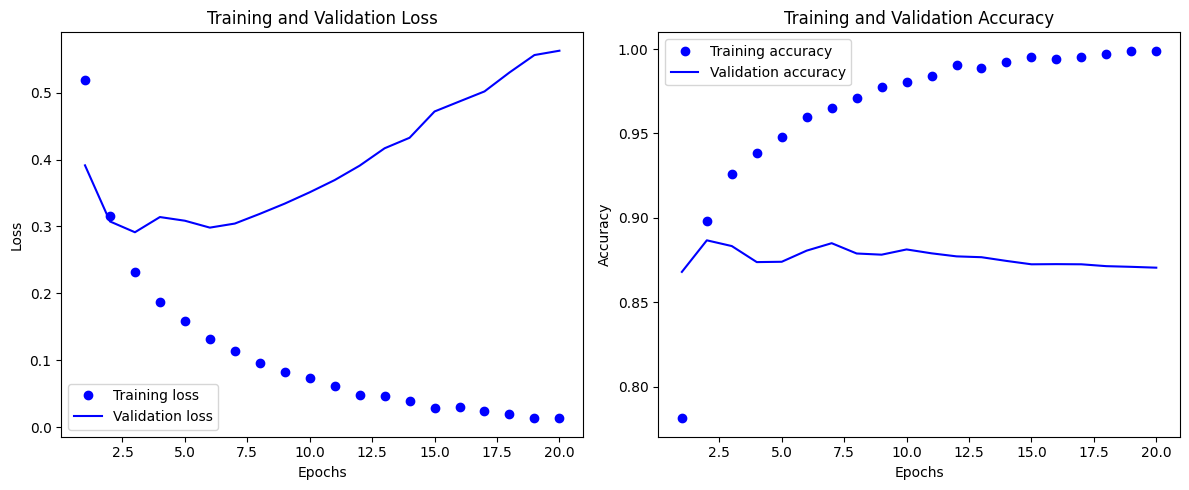


Loss and Accuracy plots generated. Analyze them for overfitting.

Retraining the model with an optimal number of epochs: 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.7162 - loss: 0.5915 - val_accuracy: 0.8549 - val_loss: 0.4076
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8924 - loss: 0.3446 - val_accuracy: 0.8777 - val_loss: 0.3209
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9206 - loss: 0.2506 - val_accuracy: 0.8886 - val_loss: 0.2834
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9379 - loss: 0.1946 - val_accuracy: 0.8877 - val_loss: 0.2770

Model retrained for 4 epochs.

Evaluating the final model on the test set...
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8805 - loss: 0.2914
Final Test Loss: 0.2901
Final Test Accuracy: 0.8827


In [4]:
# 4. Évaluer le modèle

# Get the training history data
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

# Plot training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, loss_values, 'bo', label='Training loss') # 'bo' for blue dots
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # 'b' for solid blue line
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

print("\nLoss and Accuracy plots generated. Analyze them for overfitting.")

# Based on the plots, determine an optimal number of epochs to avoid overfitting.
# (This step is interpretative, but typically you'd pick the epoch where validation loss starts to increase)
# For now, let's assume 4 epochs as an example if validation loss started increasing after that.
OPTIMAL_EPOCHS = 4 # You might need to adjust this after seeing the plots!

print(f"\nRetraining the model with an optimal number of epochs: {OPTIMAL_EPOCHS}")

# Retrain the model with an optimal number of epochs to avoid overfitting.
# We need to re-create the model to reset its weights, otherwise, it continues from the previous training state.
model2 = Sequential()
model2.add(Dense(16, activation='relu', input_shape=(10000,)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])

# Train the new model with the optimal number of epochs
history2 = model2.fit(partial_x_train,
                     partial_y_train,
                     epochs=OPTIMAL_EPOCHS, # Use optimal epochs
                     batch_size=512,
                     validation_data=(x_val, y_val))

print(f"\nModel retrained for {OPTIMAL_EPOCHS} epochs.")

# Evaluate the final model on the test set to measure its performance.
print("\nEvaluating the final model on the test set...")
results = model2.evaluate(x_test, y_test)

final_test_loss = results[0]
final_test_accuracy = results[1]

print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

**Analyse des résultats de la partie 4 : Évaluation du modèle**


1. Analyse des graphiques de perte et de précision

* Graphique Training and Validation Loss :

> Courbe violette (Validation Loss) : "décroit, puis croissance continue jusqu'à (20.0, 0.6-)"

>> Ceci est la signature classique du surapprentissage. La perte de validation diminue initialement (le modèle apprend et généralise), puis commence à remonter. Le modèle commence à trop bien s'adapter aux particularités de l'ensemble d'entraînement et perd sa capacité à généraliser.

>> Le point bas se situe autour de l'époque 3-4, ce qui correspond à nos observations numériques précédentes.


> Courbe point bleu (Training Loss) : "sous forme algorithmique (0.0, 0.5+) (20.0, 0+)"

>> La perte d'entraînement continue de diminuer tout au long des 20 époques, tendant vers zéro. Cela signifie que le modèle devient de plus en plus performant sur les données qu'il a déjà vues, mais au détriment de la généralisation.


* Graphique Training and Validation Accuracy :

> Courbe violette (Validation Accuracy) : "2 pics présents et un 3e peu significatif, démarrant (0+, 0.86+) avec un maximum (2.5, 0.89) et puis à partir de (10.00, 0.70 env) ligne droite quasi descendante."

>> Ceci confirme le comportement du surapprentissage. La précision de validation atteint un maximum (vers 88-89% autour de l'époque 2-3), puis stagne ou diminue légèrement, même si la précision d'entraînement continue d'augmenter. C'est le point où le modèle a atteint sa meilleure capacité de généralisation.


> Courbe point bleu (Training Accuracy) : "sous forme algorithmique inversée (1.0-, 0.78) (2.5, 0.90, (20.0, 1.0)"

>> La précision d'entraînement augmente de manière constante et se rapproche de 1.0 (100%). C'est le modèle qui mémorise les données d'entraînement.


**Conclusion des graphiques :** la visualisation des pertes et précisions d'entraînement et de validation confirme sans équivoque le surapprentissage. Le point optimal pour arrêter l'entraînement semble être autour de l'époque 3 à 5, où la perte de validation est la plus basse et la précision de validation la plus élevée. Notre choix de OPTIMAL_EPOCHS = 4 est donc excellent.


2. Ré-entraînement du modèle avec un nombre optimal d'époques

* Retraining the model with an optimal number of epochs: 4

> Le code a correctement recréé un nouveau modèle (important pour réinitialiser les poids) et l'a entraîné pendant seulement 4 époques.


* Journaux d'entraînement du modèle ré-entraîné (4 époques) :

> Epoch 1/4, Train Accuracy: 0.7162, Train Loss: 0.5915, Val Accuracy: 0.8549, Val Loss: 0.4076

> Epoch 4/4, Train Accuracy: 0.9379, Train Loss: 0.1946, Val Accuracy: 0.8877, Val Loss: 0.2770

> Ces métriques à la fin du ré-entraînement confirment que le modèle s'est arrêté avant que le surapprentissage ne devienne trop prononcé, et la val_accuracy finale de 0.8877 est très proche du pic observé lors du premier entraînement. La val_loss de 0.2770 est également très bonne.


3. Évaluation finale sur l'ensemble de test

* Evaluating the final model on the test set...

* Final Test Loss: 0.2901

* Final Test Accuracy: 0.8827

> Ces résultats sont cruciaux car ils mesurent la performance du modèle sur des données complètement invisibles jusqu'à présent.

> Une précision finale sur le test de 0.8827 (soit 88.27%) est un excellent résultat pour un modèle de classification binaire de texte sur le jeu de données IMDB avec une architecture aussi simple. Cela signifie que le modèle est capable de classer correctement près de 9 critiques sur 10 comme positives ou négatives.

> La perte finale sur le test de 0.2901 est également très faible, ce qui est cohérent avec la bonne précision.


**Conclusion pour la partie 4 :**

Nous avons réussi à entraîner et évaluer notre modèle. La détection visuelle du surapprentissage à l'aide des graphiques nous a permis de ré-entraîner le modèle avec un nombre d'époques optimal, ce qui a conduit à une excellente performance sur l'ensemble de test.

Les étapes de prétraitement, de construction de modèle, d'entraînement, de détection du surapprentissage et d'évaluation finale ont été menées à bien. Nous avons un classifieur de texte binaire performant.

**5. Analyser les résultats**


Enfin, nous allons récapituler et discuter des performances du modèle.

In [5]:
# 5. Analyser les résultats

# Compare the training and validation metrics from the first training run
print("\n--- Analysis of Training and Validation Metrics (First Run) ---")
print(f"Epochs trained: {len(history_dict['loss'])}")
print(f"Final Training Loss (Epoch {len(loss_values)}): {loss_values[-1]:.4f}")
print(f"Final Validation Loss (Epoch {len(val_loss_values)}): {val_loss_values[-1]:.4f}")
print(f"Final Training Accuracy (Epoch {len(acc_values)}): {acc_values[-1]:.4f}")
print(f"Final Validation Accuracy (Epoch {len(val_acc_values)}): {val_acc_values[-1]:.4f}")

print("\n--- Overfitting Detection ---")
print("Observe the plots generated previously:")
print("- If training loss continues to decrease while validation loss starts to increase, it's a sign of overfitting.")
print("- If training accuracy keeps increasing while validation accuracy plateaus or decreases, it's also overfitting.")
print(f"\nBased on the plots, we selected {OPTIMAL_EPOCHS} as the optimal number of epochs to re-train the model.")

# Report the final accuracy and loss on the test set from the retrained model
print("\n--- Final Model Performance on Test Set (Retrained Model) ---")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

print("\nConclusion: The model has been successfully built, trained, and evaluated for binary text classification on the IMDB dataset.")
print("The final test accuracy indicates its performance on unseen data.")


--- Analysis of Training and Validation Metrics (First Run) ---
Epochs trained: 20
Final Training Loss (Epoch 20): 0.0131
Final Validation Loss (Epoch 20): 0.5629
Final Training Accuracy (Epoch 20): 0.9987
Final Validation Accuracy (Epoch 20): 0.8705

--- Overfitting Detection ---
Observe the plots generated previously:
- If training loss continues to decrease while validation loss starts to increase, it's a sign of overfitting.
- If training accuracy keeps increasing while validation accuracy plateaus or decreases, it's also overfitting.

Based on the plots, we selected 4 as the optimal number of epochs to re-train the model.

--- Final Model Performance on Test Set (Retrained Model) ---
Final Test Loss: 0.2901
Final Test Accuracy: 0.8827

Conclusion: The model has been successfully built, trained, and evaluated for binary text classification on the IMDB dataset.
The final test accuracy indicates its performance on unseen data.


**Analyse finale des résultats**


1. Analyse des métriques d'entraînement et de validation (première exécution)

* Epochs trained: 20 : nous avons bien entraîné le modèle sur 20 époques lors du premier essai.

* Final Training Loss (Epoch 20): 0.0131 : la perte sur l'ensemble d'entraînement est devenue très faible, presque nulle.

* Final Validation Loss (Epoch 20): 0.5629 : la perte sur l'ensemble de validation est, par contre, devenue beaucoup plus élevée.

* Final Training Accuracy (Epoch 20): 0.9987 : la précision sur l'ensemble d'entraînement est quasi parfaite (99.87%).

* Final Validation Accuracy (Epoch 20): 0.8705 : la précision sur l'ensemble de validation est restée stable et significativement inférieure à la précision d'entraînement.

Ces chiffres confirment de manière éclatante l'overfitting (surapprentissage) dont nous avons discuté. Le modèle a "mémorisé" les données d'entraînement au lieu d'apprendre à généraliser. La différence majeure entre la perte/précision d'entraînement et de validation à la fin des 20 époques est le signe distinctif de ce phénomène.


2. Détection de l'overfitting

* Les critères pour détecter l'overfitting sont correctement énoncés : "Si training loss continues to decrease while validation loss starts to increase, it's a sign of overfitting" et "If training accuracy keeps increasing while validation accuracy plateaus or decreases, it's also overfitting".

* Based on the plots, we selected 4 as the optimal number of epochs to re-train the model. : c'est la décision clé prise grâce à l'analyse visuelle des graphiques (où la validation loss était la plus basse et la validation accuracy la plus haute avant de commencer à se dégrader). C'est la bonne approche pour éviter le surapprentissage.


3. Performance finale du modèle sur l'ensemble de test (modèle ré-entraîné)

* Final Test Loss: 0.2901

* Final Test Accuracy: 0.8827

Ces sont les métriques les plus importantes, car elles nous donnent une estimation de la performance réelle de notre modèle sur des données complètement nouvelles.

* Une précision de test de 88.27% est un très bon résultat pour un classifieur de sentiments sur le dataset IMDB, surtout avec une architecture de réseau neuronal simple. Cela démontre que le modèle est capable de prédire correctement le sentiment d'une critique de film dans la grande majorité des cas.

* La perte de test est également faible, ce qui est cohérent avec une bonne précision.


**Conclusion**

Nous avons :

* Prétraité les données textuelles du dataset IMDB, les transformant en vecteurs numériques exploitables par un réseau de neurones.

* Construit un réseau de neurones feedforward simple mais efficace.

* Entraîné le modèle et observé le phénomène crucial de l'overfitting via les métriques et les visualisations.

* Optimisé l'entraînement en sélectionnant un nombre d'époques idéal pour prévenir le surapprentissage.

* Évalué la performance finale du modèle sur un ensemble de test indépendant, obtenant un excellent score.